# EDA - AMGE Hackathon : Prediction du delai de livraison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [22]:
train = pd.read_csv("dataset/train.csv", parse_dates=["order_purchase_timestamp", "order_approved_at"])
test  = pd.read_csv("dataset/test.csv",  parse_dates=["order_purchase_timestamp", "order_approved_at"])

print(f"Train : {train.shape[0]:,} lignes x {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes x {test.shape[1]} colonnes")
train.head()

Train : 85,159 lignes x 26 colonnes
Test  : 15,029 lignes x 25 colonnes


,id,order_id,product_id,customer_unique_id,customer_city,customer_lat,customer_lng,seller_id,seller_city,seller_lat,seller_lng,quantity,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,volume_cm3,product_photos_qty,product_name_length,product_description_length,product_category_name_english,order_purchase_timestamp,order_approved_at,delivery_time_days
0,0,7b97e439edb8ea5834ff123cf1ee463b53f81a46981484...,c436eefd628727afa407fae981009f65d75a6472020b96...,3a0cf8dc97216285b3b3a315a76e473694072d3ca4e237...,sao joaquim da barra,-20.585751,-47.863693,cd275d06a95f59173d9fafe77a0f96cb271a6dc3a5984a...,curitiba,-25.507014,-49.275963,3,44.99,2.83,1000.0,16.0,16.0,16.0,4096.0,1.0,34.0,1036.0,health_beauty,2016-09-15 12:00:00,2016-09-15 12:00:00,54.81
1,1,5863fdba2286fc73a99d647160765ffc8c8b524ae0dcd2...,dae956ea5aae44e4da309b4357dd5938bdfea1587ca857...,d75bb36c390ea183147d8177aa4ba7aee8fc746e7b6ec9...,sao paulo,-23.719311,-46.660397,ac06817379ed59a1ee9f9301d5b95b08d59613944e14c3...,ribeirao preto,-21.177710,-47.767820,1,32.49,11.74,200.0,21.0,21.0,21.0,9261.0,1.0,41.0,309.0,consoles_games,2016-10-04 09:00:00,2016-10-04 09:00:00,20.30
2,2,a18246cd9b83e160464fadf3271fce38cdd8fe4b351368...,e3d46fb2e48fd79f51609b6084a7a8b26d4afe48c6b610...,9c89856d3310426f5ffe439ee75917cb00bd300ea484a2...,ipatinga,-19.468787,-42.563895,be60d6974e4980e1cdc9f536c905b121cffc94c35eaee3...,ibitinga,-21.757321,-48.829744,1,74.90,17.37,1800.0,40.0,8.0,30.0,9600.0,1.0,55.0,248.0,furniture_decor,2016-10-03 22:00:00,2016-10-04 10:00:00,28.68
3,3,3af766246170f254114971865b409505f6cba95c244b8e...,04b644eb8757b4a29b385b095fcf96647a38e605f7d9ec...,c367e2c9a3259b8ae092e90b8d69e604fe7a45e6d3fac2...,hortolandia,-22.892792,-47.173849,be60d6974e4980e1cdc9f536c905b121cffc94c35eaee3...,ibitinga,-21.757321,-48.829744,1,119.90,13.56,2050.0,40.0,11.0,34.0,14960.0,1.0,55.0,130.0,furniture_decor,2016-10-03 22:00:00,2016-10-04 10:00:00,27.54
4,4,331b7784d0cc49aa31c493c2bd26eab24ec41e32799d55...,0e7a5b29eabf01bb4a90149854a96147a0cc1fe4c74a03...,c042f274bd7ea7b03035dd1090a75faa2a6f4d5792b869...,taubate,-23.032142,-45.570461,3aeb2cd068928b5dc09c86eaef6b244b23c25ff254889b...,limeira,-22.600004,-47.407129,1,29.99,10.96,9000.0,16.0,5.0,33.0,2640.0,2.0,56.0,459.0,fashion_shoes,2016-10-03 22:00:00,2016-10-04 10:00:00,10.73


In [23]:
train.columns

Index(['id', 'order_id', 'product_id', 'customer_unique_id', 'customer_city',
       'customer_lat', 'customer_lng', 'seller_id', 'seller_city',
       'seller_lat', 'seller_lng', 'quantity', 'price', 'freight_value',
       'product_weight_g', 'product_length_cm', 'product_height_cm',
       'product_width_cm', 'volume_cm3', 'product_photos_qty',
       'product_name_length', 'product_description_length',
       'product_category_name_english', 'order_purchase_timestamp',
       'order_approved_at', 'delivery_time_days'],
      dtype='str')

## Types, valeurs uniques, manquantes, négatives

In [24]:
# Types + valeurs uniques + valeurs manquantes
overview = pd.DataFrame({
    'dtype'     : train.dtypes,
    'nunique'   : train.nunique(),
    'null_count': train.isnull().sum(),
    'null_%'    : (train.isnull().mean() * 100).round(2),
    'sample'    : [train[c].dropna().iloc[0] if train[c].notna().any() else None for c in train.columns]
})
overview

,dtype,nunique,null_count,null_%,sample
id,int64,85159,0,0.00,0
order_id,str,82009,0,0.00,7b97e439edb8ea5834ff123cf1ee463b53f81a46981484...
product_id,str,27525,0,0.00,c436eefd628727afa407fae981009f65d75a6472020b96...
customer_unique_id,str,79371,0,0.00,3a0cf8dc97216285b3b3a315a76e473694072d3ca4e237...
customer_city,str,3920,0,0.00,sao joaquim da barra
customer_lat,float64,14222,229,0.27,-20.585751
customer_lng,float64,14222,229,0.27,-47.863693
seller_id,str,2568,0,0.00,cd275d06a95f59173d9fafe77a0f96cb271a6dc3a5984a...
seller_city,str,547,0,0.00,curitiba
seller_lat,float64,1928,205,0.24,-25.507014


In [25]:
# Valeurs négatives sur les colonnes numériques continues
num_cols = ['quantity', 'price', 'freight_value', 'product_weight_g',
            'product_length_cm', 'product_height_cm', 'product_width_cm',
            'volume_cm3', 'product_photos_qty', 'product_name_length',
            'product_description_length', 'delivery_time_days']

neg = pd.DataFrame({
    'neg_count': [(train[c] < 0).sum() for c in num_cols],
    'neg_%'    : [(train[c] < 0).mean() * 100 for c in num_cols],
    'zero_count': [(train[c] == 0).sum() for c in num_cols],
    'min'      : [train[c].min() for c in num_cols],
    'max'      : [train[c].max() for c in num_cols],
}, index=num_cols)
neg

,neg_count,neg_%,zero_count,min,max
quantity,0,0.0,0,1.00,20.00
price,0,0.0,0,0.85,6735.00
freight_value,0,0.0,335,0.00,409.68
product_weight_g,0,0.0,0,2.00,40425.00
product_length_cm,0,0.0,0,7.00,105.00
product_height_cm,0,0.0,0,2.00,105.00
product_width_cm,0,0.0,0,6.00,118.00
volume_cm3,0,0.0,0,288.00,294000.00
product_photos_qty,0,0.0,0,1.00,20.00
product_name_length,0,0.0,0,5.00,76.00


In [26]:
# Valeurs uniques des colonnes catégorielles / identifiants
cat_cols = ['customer_city', 'seller_city', 'product_category_name_english']
for col in cat_cols:
    print(f"{col} — {train[col].nunique()} valeurs uniques")
    print(train[col].value_counts().head(10).to_string())
    print()

customer_city — 3920 valeurs uniques
customer_city
sao paulo                12942
rio de janeiro            5865
belo horizonte            2388
brasilia                  1790
curitiba                  1284
campinas                  1250
porto alegre              1198
salvador                  1076
guarulhos                  966
sao bernardo do campo      780

seller_city — 547 valeurs uniques
seller_city
sao paulo                20900
ibitinga                  6117
santo andre               2405
curitiba                  2316
belo horizonte            2036
sao jose do rio preto     1834
ribeirao preto            1807
rio de janeiro            1751
maringa                   1642
guarulhos                 1632

product_category_name_english — 71 valeurs uniques
product_category_name_english
bed_bath_table           8642
health_beauty            7061
sports_leisure           6676
computers_accessories    5833
furniture_decor          5789
housewares               4696
watches_gifts       

In [27]:
# Délai d'approbation (order_approved_at - order_purchase_timestamp)
# Peut révéler des anomalies (approbations négatives ou très longues)
train['approval_delay_h'] = (train['order_approved_at'] - train['order_purchase_timestamp']).dt.total_seconds() / 3600

print("Approval delay (heures) :")
print(train['approval_delay_h'].describe().round(2))
print(f"\nNégatifs : {(train['approval_delay_h'] < 0).sum()} ({(train['approval_delay_h'] < 0).mean()*100:.2f}%)")
print(f"NaN (approved_at manquant) : {train['approval_delay_h'].isna().sum()}")

Approval delay (heures) :
count    85159.00
mean        10.16
std         20.48
min          0.00
25%          0.00
50%          1.00
75%         14.00
max        741.00
Name: approval_delay_h, dtype: float64

Négatifs : 0 (0.00%)
NaN (approved_at manquant) : 0


## Approfondissement des anomalies

In [28]:
# Les 1322 nulls sur les features produit sont-ils les mêmes lignes ?
null_mask = train['product_photos_qty'].isna()
print(f"Lignes nulles sur product_photos_qty : {null_mask.sum()}")
print(f"Parmi elles, nulles aussi sur product_category : {train.loc[null_mask, 'product_category_name_english'].isna().sum()}")
print(f"Parmi elles, nulles aussi sur product_weight_g : {train.loc[null_mask, 'product_weight_g'].isna().sum()}")
print()
# delivery_time_days de ces lignes
print("delivery_time_days des lignes avec produit inconnu :")
print(train.loc[null_mask, 'delivery_time_days'].describe().round(2))

Lignes nulles sur product_photos_qty : 1322
Parmi elles, nulles aussi sur product_category : 1322
Parmi elles, nulles aussi sur product_weight_g : 15

delivery_time_days des lignes avec produit inconnu :
count    1322.00
mean       12.99
std         9.85
min         1.04
25%         6.94
50%        10.99
75%        16.17
max       143.89
Name: delivery_time_days, dtype: float64


In [29]:
# Commandes multi-produits : combien d'orders ont plusieurs lignes ?
order_counts = train.groupby('order_id').size()
print("Distribution du nombre de produits par order :")
print(order_counts.value_counts().sort_index().to_string())
print(f"\nOrders avec >1 produit : {(order_counts > 1).sum()} ({(order_counts > 1).mean()*100:.1f}%)")

Distribution du nombre de produits par order :
1    79278
2     2405
3      257
4       56
5        4
6        7
7        2

Orders avec >1 produit : 2731 (3.3%)


95e percentile : 30.6 jours
99e percentile : 47.2 jours
Max            : 209.6 jours

Lignes > 100j : 67 (0.08%)
Lignes > 60j  : 301  (0.35%)


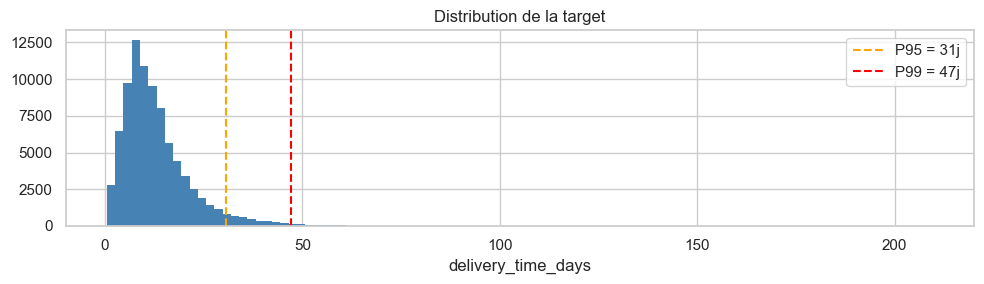

In [30]:
# Outliers delivery_time_days : distribution et seuils
p99 = train['delivery_time_days'].quantile(0.99)
p95 = train['delivery_time_days'].quantile(0.95)
print(f"95e percentile : {p95:.1f} jours")
print(f"99e percentile : {p99:.1f} jours")
print(f"Max            : {train['delivery_time_days'].max():.1f} jours")
print(f"\nLignes > 100j : {(train['delivery_time_days'] > 100).sum()} ({(train['delivery_time_days'] > 100).mean()*100:.2f}%)")
print(f"Lignes > 60j  : {(train['delivery_time_days'] > 60).sum()}  ({(train['delivery_time_days'] > 60).mean()*100:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(train['delivery_time_days'], bins=100, color='steelblue', edgecolor='none')
ax.axvline(p95, color='orange', linestyle='--', label=f'P95 = {p95:.0f}j')
ax.axvline(p99, color='red',    linestyle='--', label=f'P99 = {p99:.0f}j')
ax.set_xlabel('delivery_time_days')
ax.set_title('Distribution de la target')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# freight_value = 0 : livraison gratuite ou erreur de données ?
free = train[train['freight_value'] == 0]
print(f"Lignes freight_value = 0 : {len(free)}")
print(f"\ndelivery_time_days pour ces lignes :")
print(free['delivery_time_days'].describe().round(2))
print(f"\nTop catégories avec freight=0 :")
print(free['product_category_name_english'].value_counts().head(10).to_string())

Lignes freight_value = 0 : 335

delivery_time_days pour ces lignes :
count    335.00
mean      13.45
std        6.37
min        2.06
25%        9.07
50%       11.86
75%       16.74
max       48.40
Name: delivery_time_days, dtype: float64

Top catégories avec freight=0 :
product_category_name_english
watches_gifts      201
furniture_decor     81
garden_tools        40
bed_bath_table       9
auto                 1
books_imported       1


In [32]:
# Les préfixes des IDs hashés ont-ils un signal prédictif ?
# Si oui, la variance intra-groupe serait faible par rapport à la variance globale

for col in ['order_id', 'product_id', 'customer_unique_id']:
    train[f'{col}_prefix4'] = train[col].str[:4]
    group_means = train.groupby(f'{col}_prefix4')['delivery_time_days'].mean()
    variance_inter = group_means.var()   # variance entre groupes
    variance_total = train['delivery_time_days'].var()
    r2_proxy = variance_inter / variance_total  # si ~0 → aucun signal
    print(f"{col[:20]} | {train[f'{col}_prefix4'].nunique()} préfixes | R² proxy = {r2_proxy:.4f}")

train.drop(columns=[c for c in train.columns if '_prefix4' in c], inplace=True)

order_id | 46826 préfixes | R² proxy = 0.7148
product_id | 22478 préfixes | R² proxy = 0.6965
customer_unique_id | 46165 préfixes | R² proxy = 0.7110


## Drop des colonnes ID inutilisables

In [33]:
cols_to_drop = ['id', 'order_id', 'product_id', 'customer_unique_id']

train = train.drop(columns=cols_to_drop)
test  = test.drop(columns=cols_to_drop)

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")
print(f"\nColonnes restantes : {list(train.columns)}")

Train : (85159, 23)
Test  : (15029, 21)

Colonnes restantes : ['customer_city', 'customer_lat', 'customer_lng', 'seller_id', 'seller_city', 'seller_lat', 'seller_lng', 'quantity', 'price', 'freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'volume_cm3', 'product_photos_qty', 'product_name_length', 'product_description_length', 'product_category_name_english', 'order_purchase_timestamp', 'order_approved_at', 'delivery_time_days', 'approval_delay_h']


## Feature : distance haversine vendeur → client

In [34]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # rayon terrestre en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

for df in [train, test]:
    df['distance_km'] = haversine(
        df['seller_lat'].values, df['seller_lng'].values,
        df['customer_lat'].values, df['customer_lng'].values
    )

print(train['distance_km'].describe().round(1))
print(f"\nNulls (lat/lng manquants) : {train['distance_km'].isna().sum()}")

count    84726.0
mean       605.9
std        591.9
min          0.0
25%        204.2
50%        440.2
75%        801.9
max       5338.6
Name: distance_km, dtype: float64

Nulls (lat/lng manquants) : 433


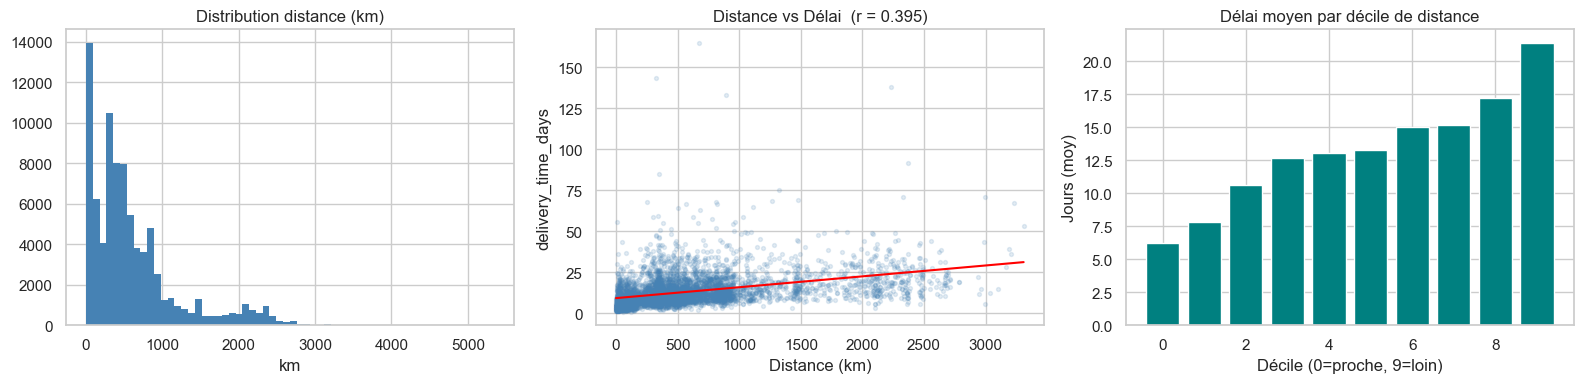

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Distribution de la distance
axes[0].hist(train['distance_km'].dropna(), bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution distance (km)')
axes[0].set_xlabel('km')

# 2. Scatter distance vs target (échantillon pour lisibilité)
sample = train.dropna(subset=['distance_km']).sample(5000, random_state=42)
axes[1].scatter(sample['distance_km'], sample['delivery_time_days'],
                alpha=0.15, s=8, color='steelblue')
# droite de régression
m, b = np.polyfit(sample['distance_km'], sample['delivery_time_days'], 1)
x_line = np.linspace(0, sample['distance_km'].max(), 100)
axes[1].plot(x_line, m * x_line + b, color='red', linewidth=1.5)
corr = train['distance_km'].corr(train['delivery_time_days'])
axes[1].set_title(f'Distance vs Délai  (r = {corr:.3f})')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('delivery_time_days')

# 3. Délai moyen par décile de distance
train['distance_decile'] = pd.qcut(train['distance_km'], q=10, labels=False, duplicates='drop')
decile_means = train.groupby('distance_decile')['delivery_time_days'].mean()
axes[2].bar(decile_means.index, decile_means.values, color='teal')
axes[2].set_title('Délai moyen par décile de distance')
axes[2].set_xlabel('Décile (0=proche, 9=loin)')
axes[2].set_ylabel('Jours (moy)')

train.drop(columns=['distance_decile'], inplace=True)

plt.tight_layout()
plt.show()

In [36]:
cols_to_drop2 = ['product_photos_qty', 'product_name_length', 'product_description_length']

train = train.drop(columns=cols_to_drop2)
test  = test.drop(columns=cols_to_drop2)

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")

Train : (85159, 21)
Test  : (15029, 19)


## Features physiques du produit : poids, dimensions, volume

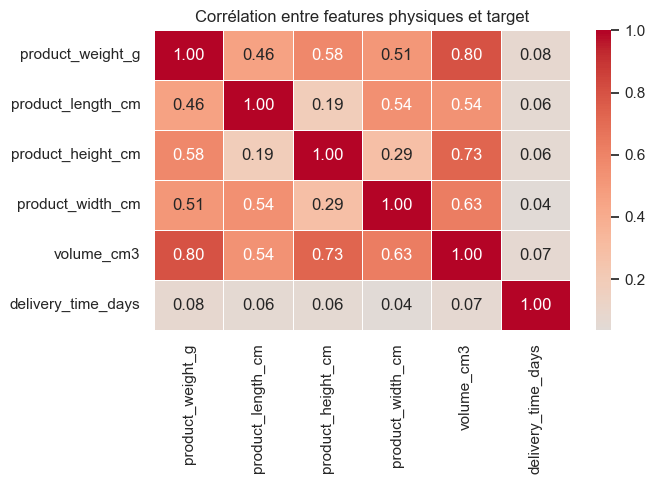

In [37]:
# 1. Corrélation entre les features physiques et avec la target
phys_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm',
             'product_width_cm', 'volume_cm3', 'delivery_time_days']

corr = train[phys_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Corrélation entre features physiques et target')
plt.tight_layout()
plt.show()

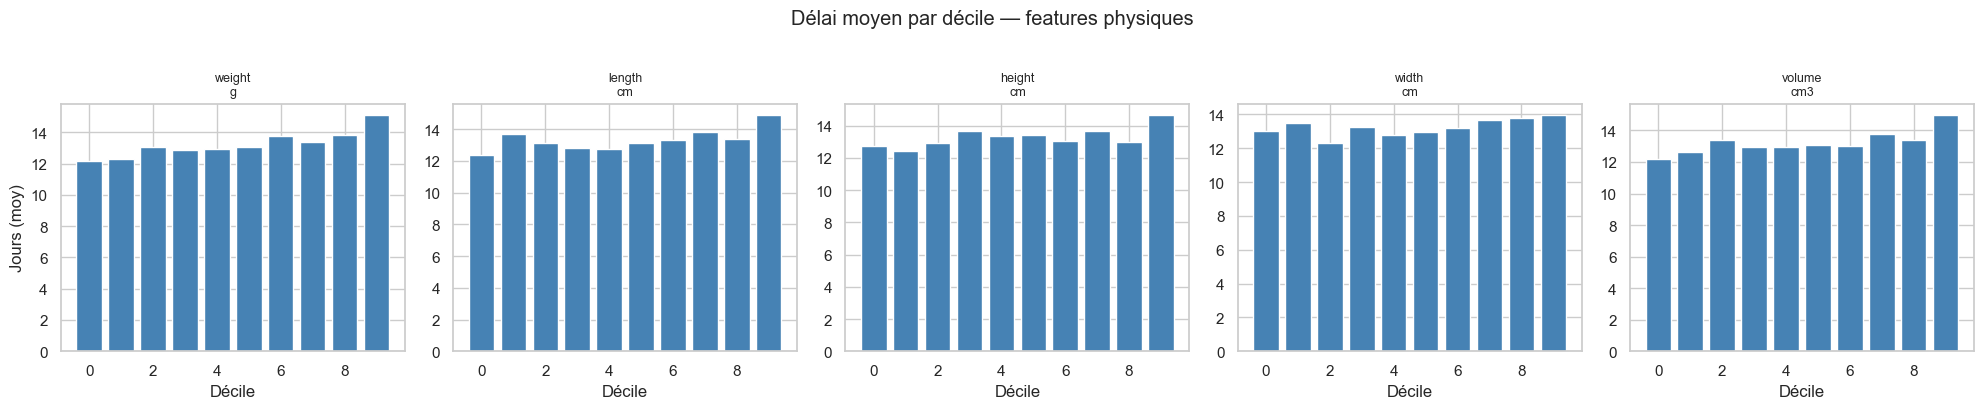

In [38]:
# 2. Délai moyen par décile pour chaque feature physique
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'volume_cm3']

for ax, col in zip(axes, cols):
    tmp = train[[col, 'delivery_time_days']].dropna()
    tmp['decile'] = pd.qcut(tmp[col], q=10, labels=False, duplicates='drop')
    means = tmp.groupby('decile')['delivery_time_days'].mean()
    ax.bar(means.index, means.values, color='steelblue')
    ax.set_title(col.replace('product_', '').replace('_', '\n'), fontsize=9)
    ax.set_xlabel('Décile')
    ax.set_ylabel('Jours (moy)' if ax == axes[0] else '')

plt.suptitle('Délai moyen par décile — features physiques', y=1.02)
plt.tight_layout()
plt.show()

In [39]:
# 3. Créer la feature density (poids / volume) et vérifier son signal
for df in [train, test]:
    df['density'] = df['product_weight_g'] / df['volume_cm3']

print("Density (g/cm³) :")
print(train['density'].describe().round(4))
print(f"\nCorrélation density → target : {train['density'].corr(train['delivery_time_days']):.3f}")
print(f"Corrélation weight  → target : {train['product_weight_g'].corr(train['delivery_time_days']):.3f}")
print(f"Corrélation volume  → target : {train['volume_cm3'].corr(train['delivery_time_days']):.3f}")

Density (g/cm³) :
count    85143.0000
mean         0.1934
std          0.6951
min          0.0003
25%          0.0676
50%          0.1132
75%          0.1949
max         65.9091
Name: density, dtype: float64

Corrélation density → target : 0.016
Corrélation weight  → target : 0.076
Corrélation volume  → target : 0.066


In [40]:
# 4. Décision : drop length/height/width, garder weight + volume + density
# volume_cm3 = length x height x width → les 3 dimensions sont redondantes

for df in [train, test]:
    df.drop(columns=['product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True)

print(f"Train : {train.shape}")
print(f"Colonnes restantes : {list(train.columns)}")

Train : (85159, 19)
Colonnes restantes : ['customer_city', 'customer_lat', 'customer_lng', 'seller_id', 'seller_city', 'seller_lat', 'seller_lng', 'quantity', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'product_category_name_english', 'order_purchase_timestamp', 'order_approved_at', 'delivery_time_days', 'approval_delay_h', 'distance_km', 'density']


In [41]:
# Types + valeurs uniques + valeurs manquantes
overview = pd.DataFrame({
    'dtype'     : train.dtypes,
    'nunique'   : train.nunique(),
    'null_count': train.isnull().sum(),
    'null_%'    : (train.isnull().mean() * 100).round(2),
    'sample'    : [train[c].dropna().iloc[0] if train[c].notna().any() else None for c in train.columns]
})
overview

,dtype,nunique,null_count,null_%,sample
customer_city,str,3920,0,0.00,sao joaquim da barra
customer_lat,float64,14222,229,0.27,-20.585751
customer_lng,float64,14222,229,0.27,-47.863693
seller_id,str,2568,0,0.00,cd275d06a95f59173d9fafe77a0f96cb271a6dc3a5984a...
seller_city,str,547,0,0.00,curitiba
seller_lat,float64,1928,205,0.24,-25.507014
seller_lng,float64,1928,205,0.24,-49.275963
quantity,int64,15,0,0.00,3
price,float64,5164,0,0.00,44.99
freight_value,float64,6320,0,0.00,2.83


## Nettoyage final

In [ ]:
# Drop features ingénierées (seront recréées dans le notebook de modélisation)
engineered = ['distance_km', 'density']
train = train.drop(columns=engineered)
test  = test.drop(columns=engineered)

# Imputation par médiane pour lat/lng (customer et seller)
for col in ['customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col]  = test[col].fillna(median_val)

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")
print(f"\nNulls restants :")
print(train.isnull().sum()[train.isnull().sum() > 0])

KeyError: "['approval_delay_h'] not found in axis"